# CNN + Dropout + Data Augmentation on MNIST
### Recognizes handwritten digits 0-9

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


## Step 1 — Load MNIST Dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to 0-1 and add channel dimension
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1)  / 255.0

print('Train:', x_train.shape)
print('Test: ', x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28, 1)
Test:  (10000, 28, 28, 1)


## Step 2 — Preview Some Images

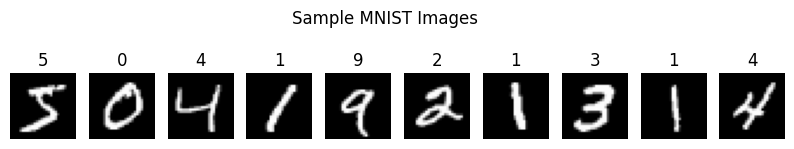

In [ ]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i, :, :, 0], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.suptitle('Sample MNIST Images')
plt.show()

## Step 3 — Data Augmentation
Randomly rotates, zooms, and shifts images to help the model generalize.

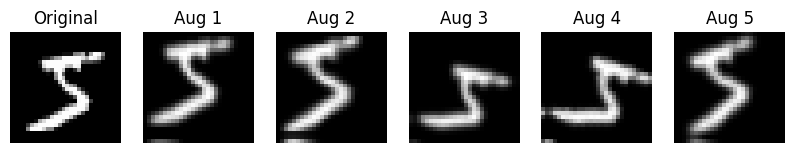

In [ ]:
augment = keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

# Show original vs augmented
sample = x_train[:1]
plt.figure(figsize=(10, 2))
plt.subplot(1, 6, 1)
plt.imshow(sample[0, :, :, 0], cmap='gray')
plt.title('Original')
plt.axis('off')
for i in range(2, 7):
    aug = augment(sample, training=True)
    plt.subplot(1, 6, i)
    plt.imshow(aug[0, :, :, 0], cmap='gray')
    plt.title(f'Aug {i-1}')
    plt.axis('off')
plt.show()

## Step 4 — Build CNN Model
- **Conv2D** layers extract features from the image
- **Dropout** randomly turns off neurons to prevent overfitting
- **Dense** layer classifies into 10 digits

In [ ]:
model = keras.Sequential([
    augment,

    layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(28,28,1)),
    layers.MaxPooling2D(2),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 28, 28, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 28, 28, 32)        │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 14, 14, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 14, 14, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 7, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 7, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 3136)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 10)                │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5 — Train the Model

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8095 - loss: 0.5827 - val_accuracy: 0.9762 - val_loss: 0.0752
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9184 - loss: 0.2633 - val_accuracy: 0.9810 - val_loss: 0.0588
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9393 - loss: 0.2015 - val_accuracy: 0.9828 - val_loss: 0.0553
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9472 - loss: 0.1761 - val_accuracy: 0.9847 - val_loss: 0.0498
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9541 - loss: 0.1546 - val_accuracy: 0.9884 - val_loss: 0.0375
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9561 - loss: 0.1462 - val_accuracy: 0.9864 - val_loss: 0.0455
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9608 - loss: 0.1330 - val_accuracy: 0.9861 - val_loss: 0.0470
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9627 - loss: 0.1258 - val_accuracy: 

## Step 6 — Accuracy & Loss Graphs

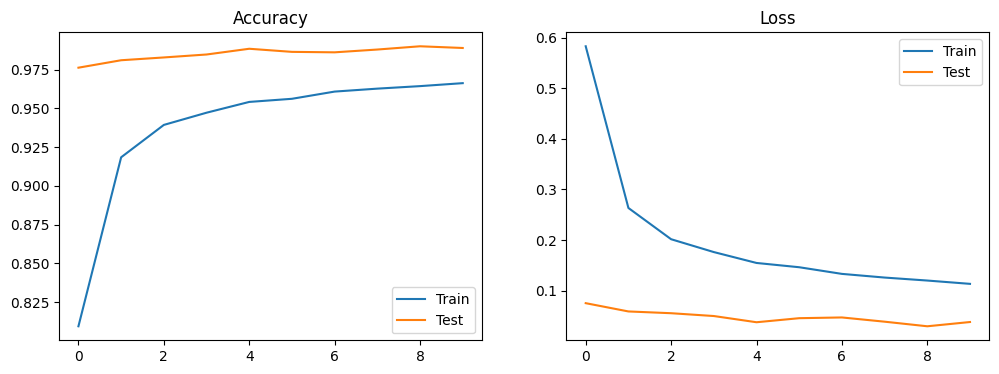

Test Accuracy: 98.89%


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history['accuracy'], label='Train')
ax[0].plot(history.history['val_accuracy'], label='Test')
ax[0].set_title('Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train')
ax[1].plot(history.history['val_loss'], label='Test')
ax[1].set_title('Loss')
ax[1].legend()

plt.show()

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc*100:.2f}%')

## Step 7 — Upload Your Own Digit Image & Get Prediction
Run this cell, click **Upload**, choose a PNG/JPG of a handwritten digit.

In [ ]:
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

def predict_image(img):
    img = img.convert('L').resize((28, 28))   # grayscale + resize
    arr = np.array(img, dtype='float32')
    if arr.mean() > 128:                       # white background -> invert
        arr = 255 - arr
    arr = arr / 255.0
    arr = arr.reshape(1, 28, 28, 1)
    probs = model.predict(arr, verbose=0)[0]
    return np.argmax(probs), probs

upload = widgets.FileUpload(accept='.png,.jpg,.jpeg', multiple=False)
out = widgets.Output()

def on_upload(change):
    with out:
        clear_output(wait=True)
        file_info = list(upload.value.values())[0]
        img = Image.open(io.BytesIO(file_info['content']))
        digit, probs = predict_image(img)

        fig, ax = plt.subplots(1, 2, figsize=(9, 3))
        ax[0].imshow(img, cmap='gray')
        ax[0].set_title('Your Image')
        ax[0].axis('off')

        colors = ['steelblue'] * 10
        colors[digit] = 'green'
        ax[1].bar(range(10), probs * 100, color=colors)
        ax[1].set_xticks(range(10))
        ax[1].set_ylabel('Confidence %')
        ax[1].set_title(f'Predicted: {digit}  ({probs[digit]*100:.1f}%)')

        plt.tight_layout()
        plt.show()

upload.observe(on_upload, names='value')
display(upload, out)

FileUpload(value={}, accept='.png,.jpg,.jpeg', description='Upload')

Output()